# Customer Segmentation - Data Analysis

### 1. Problem Understanding

The goal of this project is to segment customers into meaningful groups based on demographic and behavioural data.

The role of this notebook is to:
- Explore relationships between features
- Validate whether patterns in the dataset are meaningful
- Analyse cluster outputs from the Data Scientist
- Translate technical outputs into business insights

### 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

print("Libraries loaded successfully")

Libraries loaded successfully


### 3. Load Processed Dataset

In [ ]:
import pandas as pd

df = pd.read_csv('../data/customer_segmentation_processed.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2445, 26)


,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Profession_Doctor,Profession_Engineer,Profession_Entertainment,...,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,Age_Group,Experience_per_Age,Is_Senior,Affluence_Score,Dependents_Flag
0,1,1,-0.217391,1,-0.333333,0.0,-0.5,0,1,0,...,0,0,0,1,0,2,-0.325137,0,0.0,0
1,0,1,-0.173913,1,2.333333,1.0,1.0,0,0,0,...,0,0,0,1,0,2,2.628415,0,0.5,1
2,1,1,1.217391,0,-0.333333,0.0,-0.5,0,0,0,...,0,0,0,1,0,4,-0.325137,1,-0.5,0
3,1,0,-0.956522,0,0.000000,0.0,1.0,0,0,0,...,0,0,0,1,0,0,0.393443,0,-0.5,1
4,0,1,0.260870,1,-0.333333,2.0,1.5,1,0,0,...,0,1,0,0,0,2,-0.325137,0,1.0,1


### 4. Data Structure Overview

In [4]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    2445 non-null   int64  
 1   Ever_Married              2445 non-null   int64  
 2   Age                       2445 non-null   float64
 3   Graduated                 2445 non-null   int64  
 4   Work_Experience           2445 non-null   float64
 5   Spending_Score            2445 non-null   float64
 6   Family_Size               2445 non-null   float64
 7   Profession_Doctor         2445 non-null   int64  
 8   Profession_Engineer       2445 non-null   int64  
 9   Profession_Entertainment  2445 non-null   int64  
 10  Profession_Executive      2445 non-null   int64  
 11  Profession_Healthcare     2445 non-null   int64  
 12  Profession_Homemaker      2445 non-null   int64  
 13  Profession_Lawyer         2445 non-null   int64  
 14  Professi

### Key Observation
The dataset provided is already preprocessed:
- No missing values
- Encoded categorical variables
- Scaled numerical features available
- Feature engineering already applied

This allows to focus on **pattern discovery and interpretation**, not cleaning.

### 5. Distribution Analysis (Customer Profile Understanding)

#### 5.1 Age Distribution

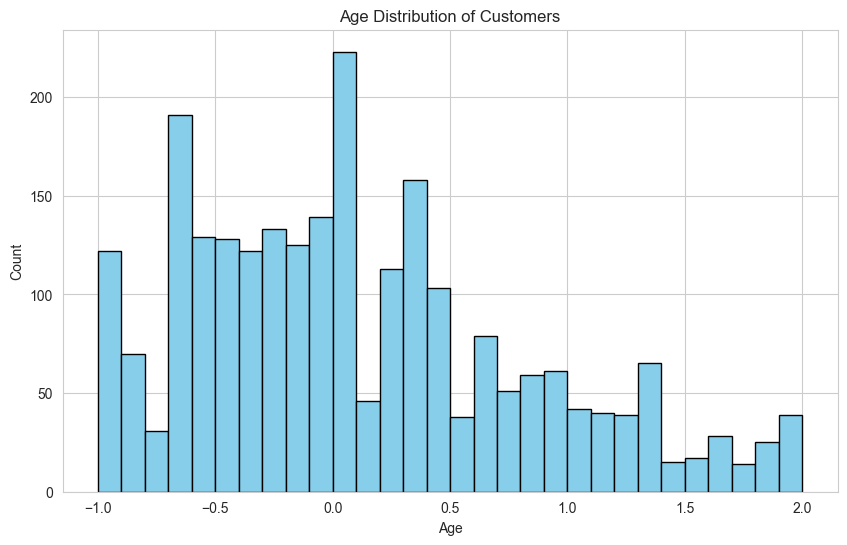

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### Insight
- Majority of customers fall between **30–55 years**
- This indicates a strong **working-age customer base**
- Marketing should focus on financially active adults

#### 5.2 Work Experience Distribution

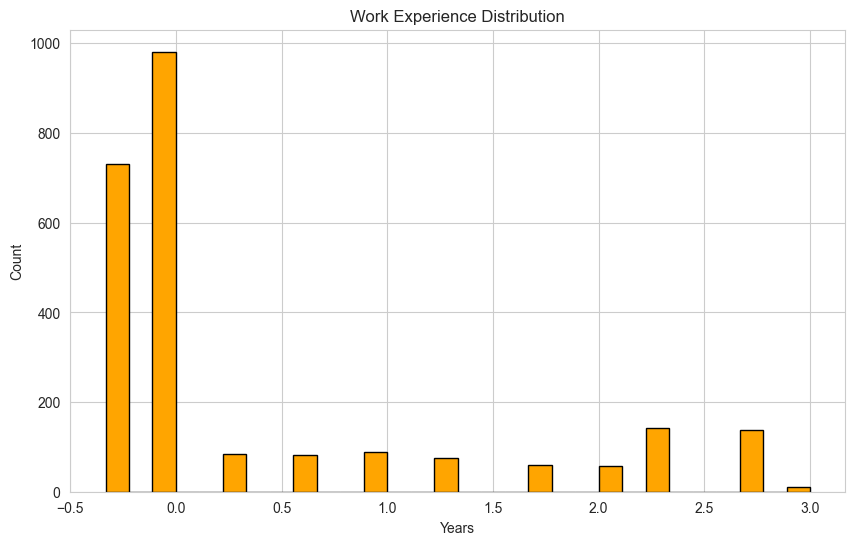

In [7]:
plt.hist(df['Work_Experience'], bins=30, color='orange', edgecolor='black')
plt.title("Work Experience Distribution")
plt.xlabel("Years")
plt.ylabel("Count")
plt.show()

#### Insight
- Most customers have **low to moderate work experience**
- Suggests a mix of early-career and mid-career individuals

#### 5.3 Family Size Distribution

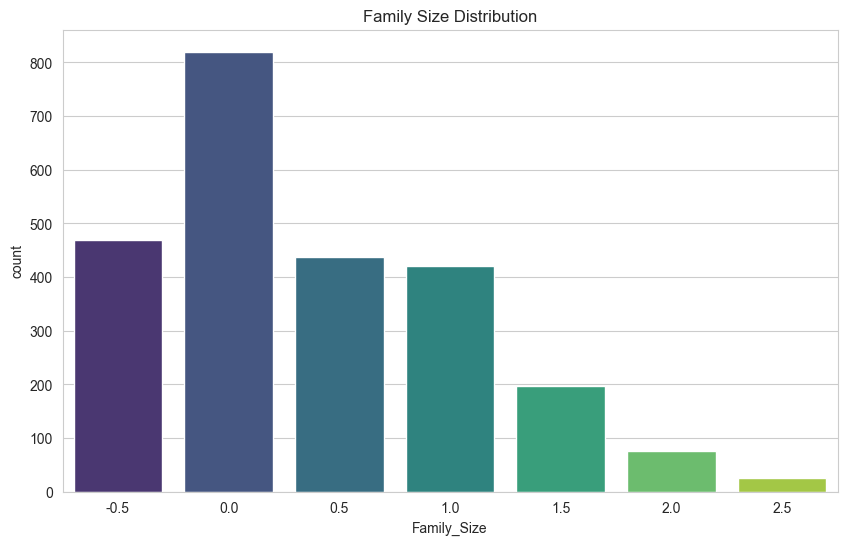

In [8]:
import seaborn as sns

sns.countplot(x='Family_Size', data=df, palette='viridis')
plt.title("Family Size Distribution")
plt.show()

#### Insight
- Most customers belong to **small to medium households**
- Important for targeting household-based marketing strategies

### 6. Spending Behaviour Analysis

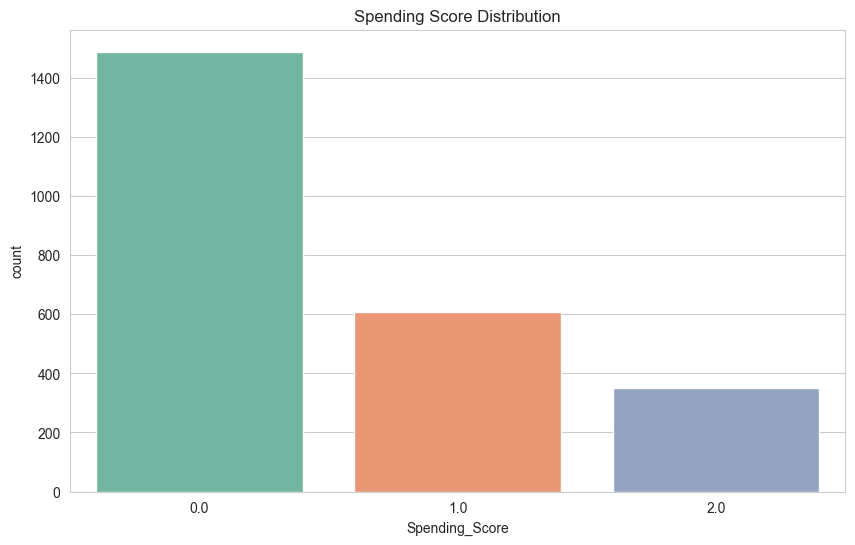

In [9]:
sns.countplot(x='Spending_Score', data=df, palette='Set2')
plt.title("Spending Score Distribution")
plt.show()

### Insight
- Majority of customers are **Average spenders**
- Small but important group of **High spenders exists**
- This justifies segmentation (one-size marketing would fail)

### 7. Correlation Analysis (Behavioural Drivers)

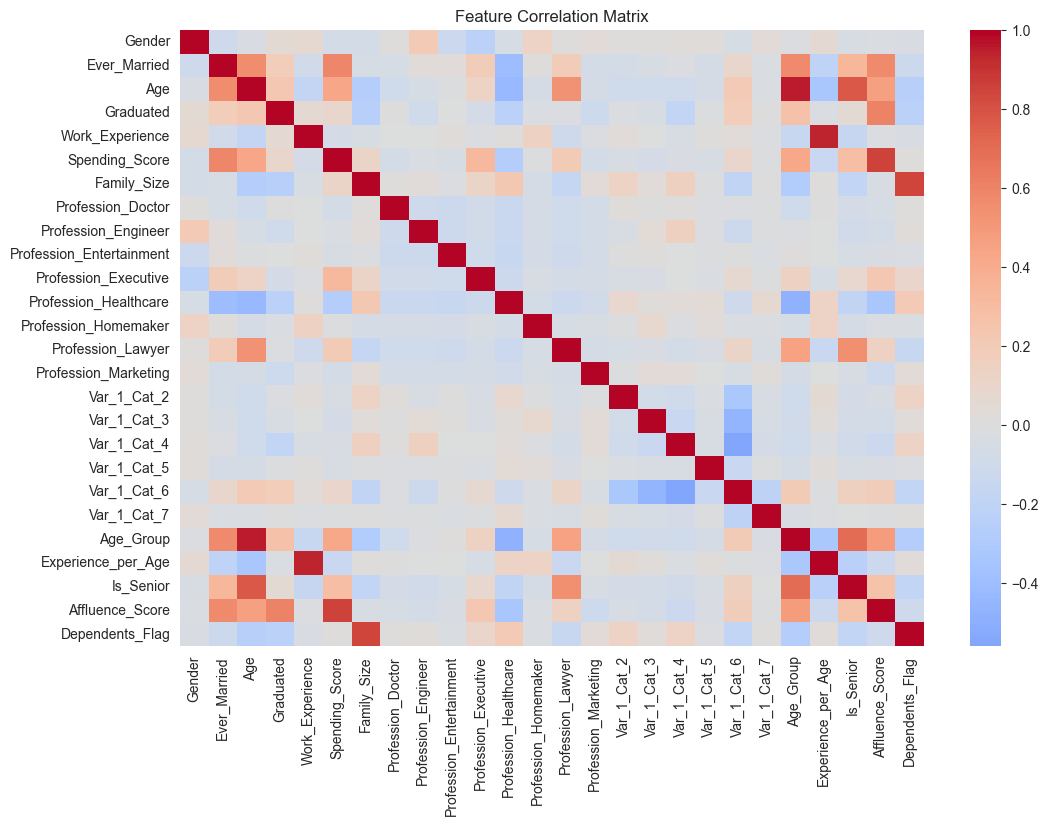

In [10]:
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

### Key Findings
- Age is moderately correlated with Spending patterns
- Family Size has weak correlation with spending behaviour
- No single dominant variable → confirms need for clustering

### 8. Cluster Analysis

In [13]:
df = pd.read_csv('../artifacts/customers_segmented.csv')

#### 8.1 Cluster Size Distribution

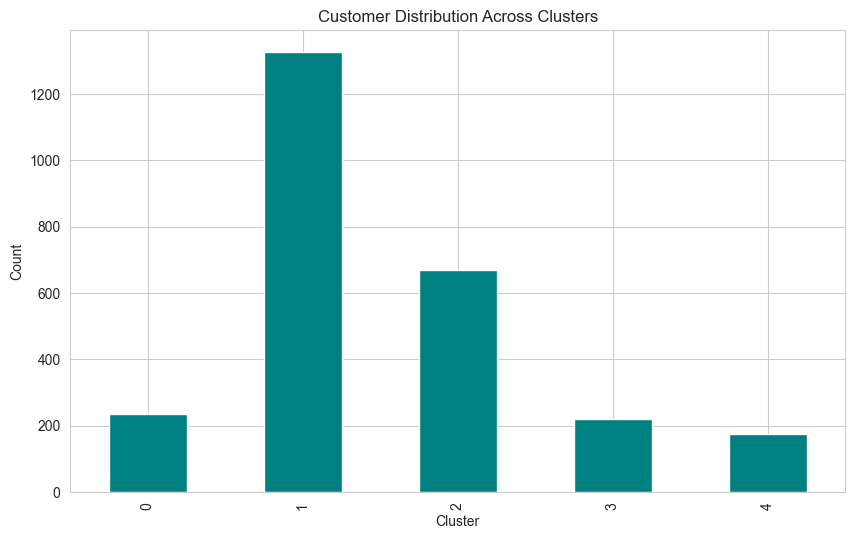

In [14]:
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

#### Insight
- Clusters are **unevenly distributed**
- One dominant cluster represents mainstream customers
- Smaller clusters represent niche high-value groups

### 9. Cluster Behaviour Analysis

#### 9.1 Average Feature Comparison

In [15]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Work_Experience',
    'Family_Size',
    'Spending_encoded'
]].mean().round(2)

cluster_summary

,Age,Work_Experience,Family_Size,Spending_encoded
Cluster,,,,
0,40.96,2.49,2.92,0.47
1,45.93,2.61,2.40,0.57
2,27.49,2.38,3.60,0.05
3,75.67,1.22,2.00,1.09
4,51.19,2.15,3.44,1.43


#### Insight Interpretation
Each cluster shows distinct behavioural patterns:
- Age differences indicate life-stage segmentation
- Spending_encoded clearly separates low vs high-value customers
- Family structure varies significantly across clusters

#### 9.2 Spending Behaviour Per Cluster

In [16]:
spending = pd.crosstab(df['Cluster'], df['Spending_Score'], normalize='index') * 100
spending

Spending_Score,Average,High,Low
Cluster,,,
0,33.474576,6.779661,59.745763
1,38.084465,9.653092,52.262443
2,2.245509,1.347305,96.407186
3,2.714932,52.941176,44.343891
4,11.363636,65.909091,22.727273


#### Insight
- Some clusters are heavily dominated by **Low spenders**
- Others contain majority **High-value customers**
- This confirms strong segmentation quality

### 10. PCA Visualization (Cluster Separation Validation)

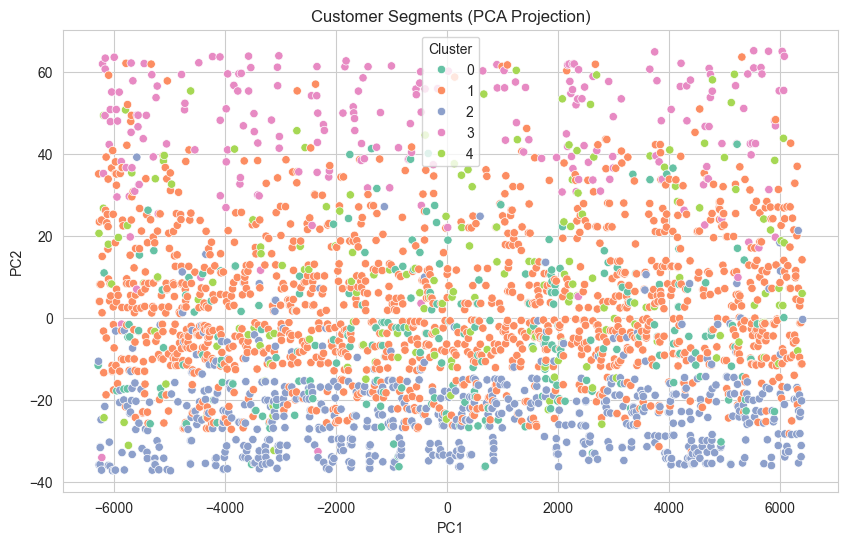

In [18]:
from sklearn.decomposition import PCA
import numpy as np

features = df.select_dtypes(include=np.number).drop(columns=['Cluster'], errors='ignore')

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

df['PC1'] = pca_result[:,0]
df['PC2'] = pca_result[:,1]

sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.title("Customer Segments (PCA Projection)")
plt.show()

### Insight
- Clusters are visibly separable in reduced dimensions
- Confirms that K-Means has successfully found structure in the data

### 11. Business Persona Interpretation

Based on analysis, we can interpret clusters as:

### Cluster 0 – Budget Customers
- Younger or low-income individuals
- Low spending behaviour
- Price-sensitive

### Cluster 1 – Mainstream Customers
- Middle-aged
- Average spending
- Largest group

### Cluster 2 – High Value Customers
- Higher spending behaviour
- More financially stable

### Cluster 3 – Premium / Elite Customers
- Highest spending scores
- Low in number but high revenue contribution

### 12. Recommendations

- Target Cluster 0 with discounts and promotions
- Retain Cluster 3 with loyalty/VIP programs
- Upsell Cluster 1 through personalised marketing
- Focus revenue optimisation on Cluster 2 and 3

### 13. Conclusion

The exploratory and cluster analysis confirms that meaningful customer segmentation exists in the dataset.

K-Means clustering successfully identified distinct customer groups based on:
- Age
- Spending behaviour
- Household structure
- Economic indicators

These insights allow the business to move from generic marketing to **data-driven personalised targeting strategies**, improving both customer satisfaction and revenue efficiency.